## Reasoning over models

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score

# black-box model imports
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils
from helper_functions import read_adult

# for reproducibility
random.seed(42)
np.random.seed(42)

# set to False to remove assertion check
assertion_check = True

In [3]:
# Loading the dataset
df, pred_atts, target, df_code = read_adult(continuous_only=False, simplified=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   race          48842 non-null  str  
 1   sex           48842 non-null  str  
 2   workclass     48842 non-null  str  
 3   education     48842 non-null  str  
 4   age           48842 non-null  int64
 5   capitalgain   48842 non-null  int64
 6   capitalloss   48842 non-null  int64
 7   hoursperweek  48842 non-null  int64
 8   class         48842 non-null  str  
dtypes: int64(4), str(5)
memory usage: 3.4 MB


In [4]:
# Encoding the dataset
df_encoded_onehot = df_code.fit_transform(df)
encoded_pred_atts = df_code.encoded_atts(pred_atts)
df_encoded_onehot.head()

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,...,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek,class
0,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,13,39,2174,0,40,0
1,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,13,50,0,0,13,0
2,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,9,38,0,0,40,0
3,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,7,53,0,0,40,0
4,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,13,28,0,0,40,0


### Train black-box models

In [5]:
# split predictive and target
X, y = df_encoded_onehot[encoded_pred_atts], df_encoded_onehot[target]

# retain test sets
X1, XT1, y1, yt1 = train_test_split(X, y, test_size=0.3, random_state=42)

# train different models
mlp = MLPClassifier(random_state=0)
mlp.fit(X1, y1)

rf = RandomForestClassifier(max_depth=3, n_estimators=100, random_state=42)
rf.fit(X1, y1)

xgb = XGBClassifier(random_state=42)
xgb.fit(X1, y1)

clf1 = DecisionTreeClassifier(max_depth=3)
clf1.fit(X1, y1)

# simple performance comparison of models
print("DT (case DT-M)   ", clf1.score(XT1, yt1))
print("MLP              ", mlp.score(XT1, yt1))
print("RF               ", rf.score(XT1, yt1))
print("XGB              ", xgb.score(XT1, yt1))

DT (case DT-M)    0.801610591687709
MLP               0.8156009008394185
RF                0.8037261994130894
XGB               0.851361495939398


In [6]:
# choose model to compare with clf1
#bb = rf
#bb = mlp
bb = xgb

In [7]:
bb_label = bb.predict(XT1)

# split the test set (XT1/xgb_labels) in two parts
XT1_train, XT1_test, bb_label_train, bb_label_test = train_test_split(XT1, bb_label, test_size=0.3, random_state=42)
#print(len(XT1_train), len(XT1_test))

# train a surrogate decision tree
clf2 = DecisionTreeClassifier(max_depth=3)
clf2.fit(XT1_train, bb_label_train)

# fidelity of the surrogate tree
print("Fidelity:", clf2.score(XT1_test, bb_label_test))

# labels predicted by bb
pd_series = pd.Series(bb_label_test)

Fidelity: 0.9206096451319381


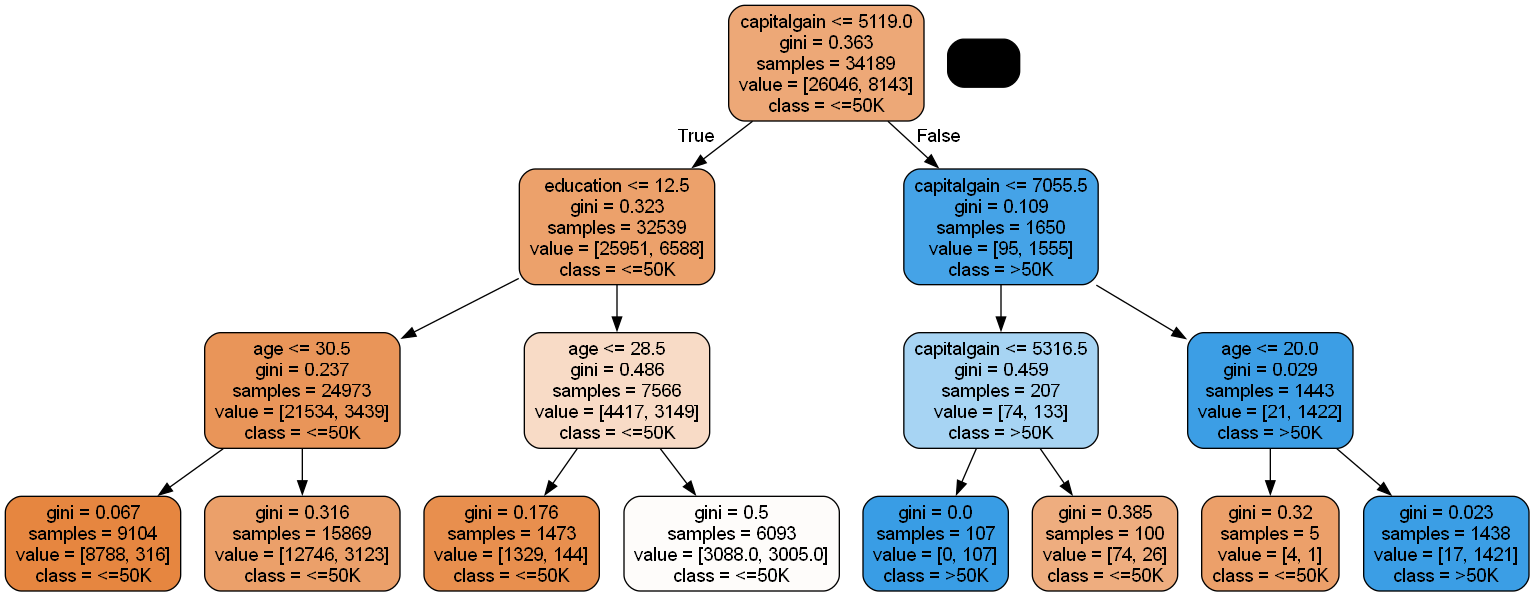

In [8]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree
dot_data = tree.export_graphviz(clf1, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

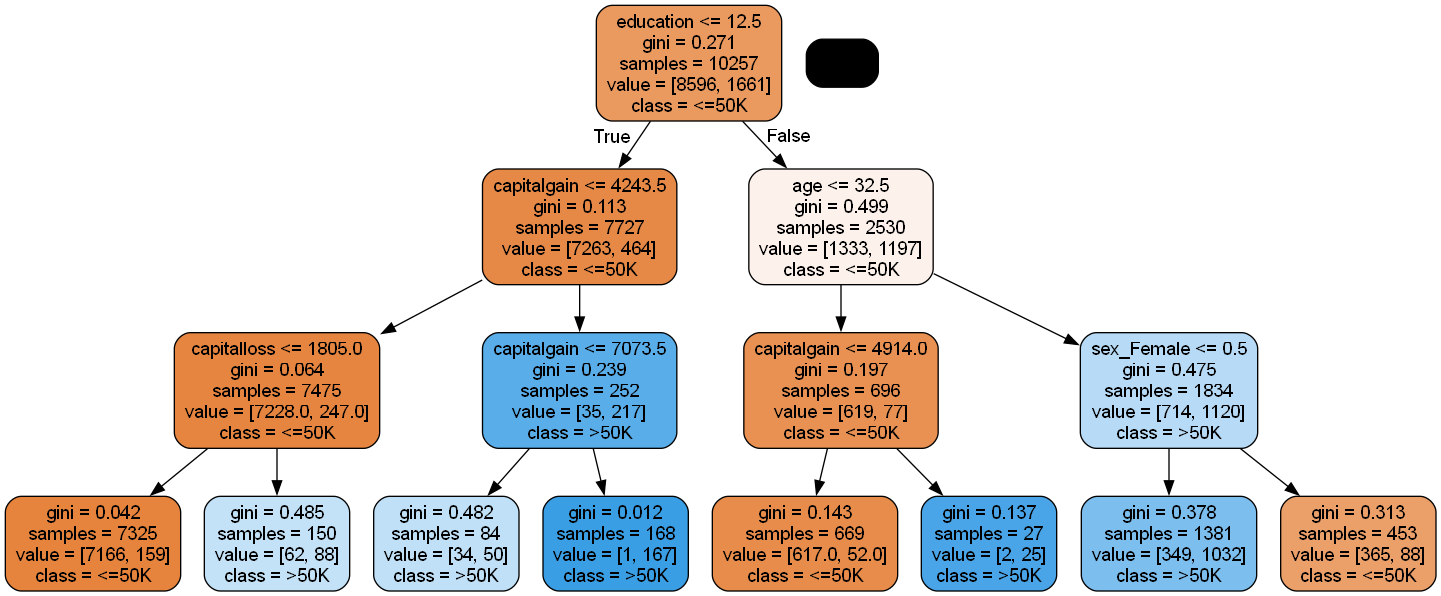

In [9]:
# visualize the decision tree
dot_data = tree.export_graphviz(clf2, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

### Explain

In [10]:
# initialise ReasonX
r = reasonx.ReasonX(pred_atts, target, df_code)
model1 = r.model(clf1, returnID=True)
model2 = r.model(clf2, returnID=True, bb=xgb)

In [11]:
# fix instance to explain
inst = 140
x_features = XT1_test.iloc[inst:(inst+1)]
x_class = bb_label_test[inst]
x_features

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,workclass_Private,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek
3707,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,10,41,7298,0,50


In [12]:
# diff models but compare over SAME data instace
# factual decision rule
r.instance('F0', features=x_features, label=x_class, model=model1)
r.instance('F1', features=x_features, label=x_class, model=model2)
r.solveopt()

---
Answer constraint: F0.race=AmerIndianEskimo,F0.sex=Male,F0.workclass=Private,F0.education=10.0,F0.age=41.0,F0.capitalgain=7298.0,F0.capitalloss=0.0,F0.hoursperweek=50.0,F1.race=AmerIndianEskimo,F1.sex=Male,F1.workclass=Private,F1.education=10.0,F1.age=41.0,F1.capitalgain=7298.0,F1.capitalloss=0.0,F1.hoursperweek=50.0
Rule satisfied by F0: IF F0.capitalgain>7055.5,F0.age>20.0 THEN >50K [0.9882, 0.0421]
Rule satisfied by F1: IF F1.education<=12.5,F1.capitalgain>7073.5 THEN >50K [0.9940, 0.0164]


In [13]:
# contrastive explanations -- instance F0
print("contrastive explanations wrt F0")
r.instance('CE0', label=1-x_class, model=model1, minconf=0.8)
r.constraint("CE0.race = F0.race, CE0.sex = F0.sex, CE0.workclass = F0.workclass, CE0.education = F0.education, CE0.age >= F0.age")
r.solveopt(project=['CE0'])
CE0_answers = r.answers()
if assertion_check:
    assert CE0_answers == ['CE0.race=AmerIndianEskimo,CE0.sex=Male,CE0.workclass=Private,CE0.education=10.0,CE0.age>=41.0,CE0.capitalgain<=5119.0']

print("\n\nminimal contrastive explanations wrt F0")
r.solveopt(minimize='l1norm(F0, CE0)', project=['CE0'], eps=0.01)
MCE0_answers = r.answers()
if assertion_check:
    assert MCE0_answers == ['CE0.race=AmerIndianEskimo,CE0.sex=Male,CE0.workclass=Private,CE0.education=10.0,CE0.age=41.0,CE0.capitalgain=5118.999999999996,CE0.capitalloss=0.0,CE0.hoursperweek=50.0']


contrastive explanations wrt F0
---
Answer constraint: CE0.race=AmerIndianEskimo,CE0.sex=Male,CE0.workclass=Private,CE0.education=10.0,CE0.age>=41.0,CE0.capitalgain<=5119.0
Contrastive rule satisfied by CE0: IF Answer constraint THEN <=50K [1.0000]
Rule satisfied by CE0: IF CE0.capitalgain<=5119.0,CE0.education<=12.5,CE0.age>30.5 THEN <=50K [0.8032, 0.4642]


minimal contrastive explanations wrt F0
---
Answer constraint: CE0.race=AmerIndianEskimo,CE0.sex=Male,CE0.workclass=Private,CE0.education=10.0,CE0.age=41.0,CE0.capitalgain=5118.999999999996,CE0.capitalloss=0.0,CE0.hoursperweek=50.0
Contrastive rule satisfied by CE0: IF Answer constraint THEN <=50K [1.0000]
Min value:0.0218
Rule satisfied by CE0: IF CE0.capitalgain<=5119.0,CE0.education<=12.5,CE0.age>30.5 THEN <=50K [0.8032, 0.4642]


In [14]:
# contrastive explanations -- instance F1

# ask for CE one after the other to avoid combinatorial effect
r.iretract('CE0') # delete instance CE0

print("contrastive explanations wrt F1")
r.instance('CE1', label=1-x_class, model=model2, minconf=0.8)
r.constraint("CE1.race = F1.race, CE1.sex = F1.sex, CE1.workclass = F1.workclass, CE1.education = F1.education, CE1.age >= F1.age")
# boundedness condition is not satisfied, enforce it!
continuous_atts = ['age', 'capitalgain', 'capitalloss', 'hoursperweek']
for f in continuous_atts:
    r.bounds(f, df[f].min(), df[f].max())
r.solveopt(project=['CE1'], eps=0.01)
CE1_answers = r.answers()
if assertion_check:
    assert CE1_answers == ['CE1.race=AmerIndianEskimo,CE1.sex=Male,CE1.workclass=Private,CE1.education=10.0,CE1.age>=41.0,CE1.age<=90.0,CE1.capitalgain>= -0.0,CE1.capitalgain<=4243.5,CE1.capitalloss>= -0.0,CE1.capitalloss<=1805.0,CE1.hoursperweek>=1.0,CE1.hoursperweek<=99.0']

print("\n\nminimal contrastive explanations wrt F1")
r.solveopt(minimize='l1norm(F1, CE1)', project=['CE1'], eps=0.01)
MCE1_answers = r.answers()
if assertion_check:
    assert MCE1_answers == ['CE1.race=AmerIndianEskimo,CE1.sex=Male,CE1.workclass=Private,CE1.education=10.0,CE1.age=41.0,CE1.capitalgain=4243.499999999996,CE1.capitalloss=0.0,CE1.hoursperweek=50.0']


contrastive explanations wrt F1
---
Answer constraint: CE1.race=AmerIndianEskimo,CE1.sex=Male,CE1.workclass=Private,CE1.education=10.0,CE1.age>=41.0,CE1.age<=90.0,CE1.capitalgain>= -0.0,CE1.capitalgain<=4243.5,CE1.capitalloss>= -0.0,CE1.capitalloss<=1805.0,CE1.hoursperweek>=1.0,CE1.hoursperweek<=99.0
Contrastive rule satisfied by CE1: IF Answer constraint THEN <=50K [1.0000]
Rule satisfied by CE1: IF CE1.education<=12.5,CE1.capitalgain<=4243.5,CE1.capitalloss<=1805.0 THEN <=50K [0.9783, 0.7141]


minimal contrastive explanations wrt F1
---
Answer constraint: CE1.race=AmerIndianEskimo,CE1.sex=Male,CE1.workclass=Private,CE1.education=10.0,CE1.age=41.0,CE1.capitalgain=4243.499999999996,CE1.capitalloss=0.0,CE1.hoursperweek=50.0
Contrastive rule satisfied by CE1: IF Answer constraint THEN <=50K [1.0000]
Min value:0.0305
Rule satisfied by CE1: IF CE1.education<=12.5,CE1.capitalgain<=4243.5,CE1.capitalloss<=1805.0 THEN <=50K [0.9783, 0.7141]


In [15]:
# COMBINATORIAL
r.reset(keep_model=True)
r.instance('F1', features=x_features, label=x_class, model=model2)
r.instance('CE1', label=1-x_class, model=model2, minconf=0.8)

print("contrastive explanations wrt F1")
for answ in CE0_answers:
    # contraints on instance 0 must be also valid for instance 1
    constraints_ = answ.replace("CE0", "CE1")
    r.constraint(constraints_)
    r.solveopt(project=['CE1'])
    r.retract(constraints_)

print("\n\nminimal contrastive explanations wrt F1")
for answ in CE0_answers:
    # contraints on instance 0 must be also valid for instance 1
    constraints_ = answ.replace("CE0", "CE1")
    r.constraint(constraints_)
    r.solveopt(minimize='l1norm(F1, CE1)', project=['CE1'])
    r.retract(constraints_)

contrastive explanations wrt F1
---
Answer constraint: CE1.race=AmerIndianEskimo,CE1.sex=Male,CE1.workclass=Private,CE1.education=10.0,CE1.age>=41.0,CE1.capitalgain<=4243.5,CE1.capitalloss<=1805.0
Contrastive rule satisfied by CE1: IF Answer constraint THEN <=50K [1.0000]
Rule satisfied by CE1: IF CE1.education<=12.5,CE1.capitalgain<=4243.5,CE1.capitalloss<=1805.0 THEN <=50K [0.9783, 0.7141]
6 constraint(s) retracted


minimal contrastive explanations wrt F1
---
Answer constraint: CE1.race=AmerIndianEskimo,CE1.sex=Male,CE1.workclass=Private,CE1.education=10.0,CE1.age=41.0,CE1.capitalgain=4243.499999999996,CE1.capitalloss=0.0,CE1.hoursperweek=50.0
Contrastive rule satisfied by CE1: IF Answer constraint THEN <=50K [1.0000]
Min value:0.0305
Rule satisfied by CE1: IF CE1.education<=12.5,CE1.capitalgain<=4243.5,CE1.capitalloss<=1805.0 THEN <=50K [0.9783, 0.7141]
6 constraint(s) retracted
